# Data mining \& clustering

The goal if this practical is to adress the folowing problem:
<center style="color:red" >  Given XXX raw, unlabeled documents, ... How to exploit/understand/represent them?</center>

In the previous week, we have seen how to represent textual data with the Bag of Words (BoW) model:
$$X =
	\begin{matrix}
	 & \textbf{t}_j \\
	 & \downarrow \\
	\textbf{d}_i \rightarrow &
	\begin{pmatrix}
	x_{1,1} & \dots & x_{1,d} \\
	\vdots & \ddots & \vdots \\
	x_{N,1} & \dots & x_{N,d} \\
	\end{pmatrix}
	\end{matrix}
	$$

From this BoW representation, we want to answer the following questions:
1. Which clustering algorithm to choose?
    - K-means, LSA, pLSA, LDA
1. What results to expect?
    - Semantics, noise cleaning, etc...
1. Which qualitative and quantitative analyses to understand the groups?
[comment]: <> (%1. Comment boucler, itérer pour améliorer la qualité du processus?)


<span style="color:magenta" > In this practical, we use a **labeled dataset** in order to evaluate performances with quantitative and well-defined metrics. </span>


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path
import sklearn
from wordcloud import WordCloud
from collections import Counter
from scipy import stats

## Data loading



In [3]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

In [4]:
# conversion BoW + tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
#vectorizer = TfidfVectorizer()
vectorizer_tfidf = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')

vectors_tfidf = vectorizer_tfidf.fit_transform(newsgroups_train.data)
print(vectors_tfidf.shape)

# sparsity measure = 44 active words over 1000 per document (157 over 130000) !!
print(vectors_tfidf.nnz / float(vectors_tfidf.shape[0])) # average number of words per document
print(1 - vectors_tfidf.nnz / vectors_tfidf.shape[0] / vectors_tfidf.shape[1]) # Sparsity proportion

(11314, 1000)
44.164928407283014
0.955835071592717


In [5]:
# retrieve words (take 10 random words)
print([(i,vectorizer_tfidf.get_feature_names_out()[i]) \
       for i in np.random.randint(vectors_tfidf.shape[1], size=10)])

[(np.int64(523), 'kill'), (np.int64(757), 'religion'), (np.int64(930), 'univ'), (np.int64(567), 'lot'), (np.int64(714), 'previous'), (np.int64(592), 'means'), (np.int64(55), '43'), (np.int64(490), 'info'), (np.int64(660), 'opinion'), (np.int64(375), 'family')]


In [6]:
# labels (only for evaluation)
Y = newsgroups_train.target
print(Y[:10])
print([newsgroups_train.target_names[i] for i in Y[:20]]) # vraie classe

[ 7  4  4  1 14 16 13  3  2  4]
['rec.autos', 'comp.sys.mac.hardware', 'comp.sys.mac.hardware', 'comp.graphics', 'sci.space', 'talk.politics.guns', 'sci.med', 'comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc', 'comp.sys.mac.hardware', 'rec.motorcycles', 'talk.religion.misc', 'comp.sys.mac.hardware', 'sci.space', 'misc.forsale', 'alt.atheism', 'comp.graphics', 'rec.autos', 'sci.electronics', 'comp.windows.x']


# 0) Word clouds
### Drawing word clouds from the raw corpus or words' frequencies :  [make word clouds !](https://github.com/amueller/word_cloud)

### Installation
If you are using pip:

`pip install wordcloud`

### If you are using conda, you can install from the conda-forge channel:

`conda install -c conda-forge wordcloud`

### Let's look at the most frequent words in this dataset

In [7]:
data = np.array(newsgroups_train.data)
corpus = "".join(data)
words = corpus.split() # optional args to choose the splitting chars
print("Nb mots=",len(words))
# Lets find the most frequence words Your code here

Nb mots= 3252437


### Plot the N frequent words and verify that its follows a Zipf law

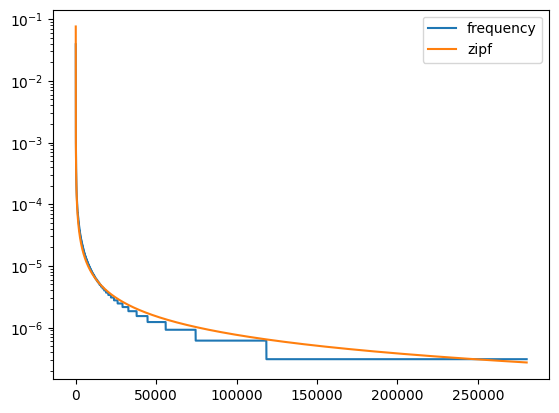

In [8]:
word_counts = Counter(words)
counts = np.sort(np.array(list(word_counts.values()), dtype=float))[::-1]
counts /= np.sum(counts)

ranks = np.arange(1, len(counts) + 1)
zipf = 1 / ranks
zipf /= np.sum(zipf)

plt.plot(ranks, counts, label="frequency")
plt.plot(ranks, zipf, label="zipf")
plt.legend()
plt.yscale("log")

### Experiment word clouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

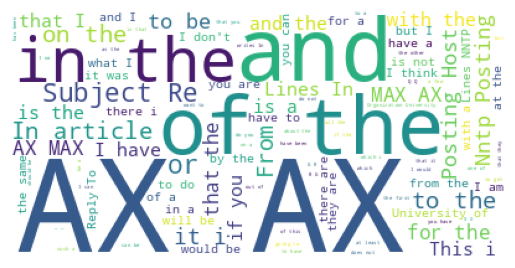

In [9]:
wordcloud = WordCloud(background_color='white', stopwords = [], max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

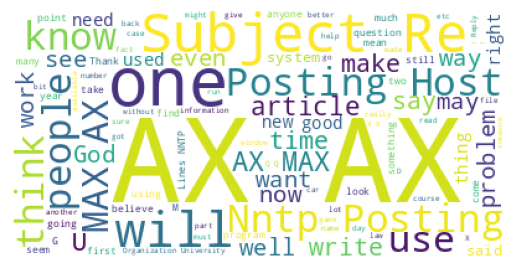

In [10]:
from wordcloud import STOPWORDS # Note: this is the default option
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")

### Use word clouds with generate\_from\_frequencies.
N.B.: retrieve the most words frequencies using a CountVectorizer

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

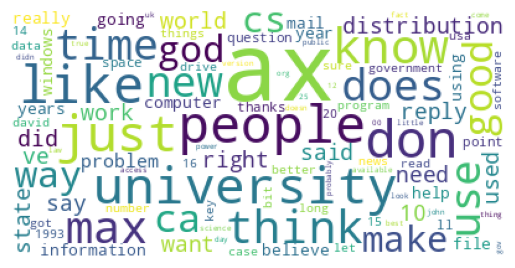

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_df=0.4, min_df=5, stop_words="english", lowercase=True, max_features=5000)
vectors = vectorizer.fit_transform(newsgroups_train.data)

freqs = {word : int(freq) for word, freq in zip(vectorizer.get_feature_names_out(),
                                           vectors.sum(axis=0).A1)}

vocab = vectorizer.get_feature_names_out()
cloud=wordcloud.generate_from_frequencies(freqs)

plt.figure()
plt.imshow(cloud)
plt.axis("off")


### Drawing word clouds from classes


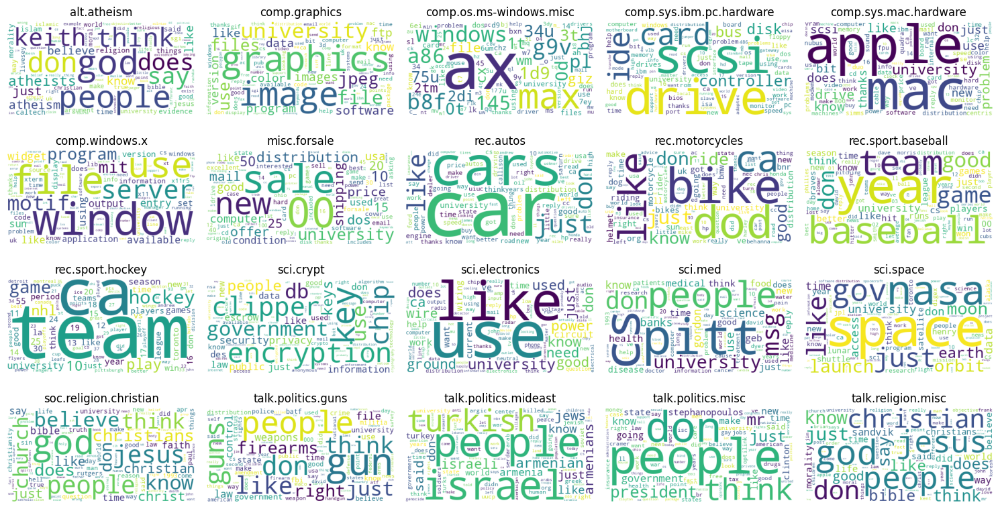

In [12]:
fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()
for target in np.unique(newsgroups_train.target):
    # Extract data related to target
    idx = np.where(newsgroups_train.target == target)[0]
    data_target = [newsgroups_train.data[i] for i in idx]
    
    # Extract frequencies
    vectors = CountVectorizer(vocabulary=vocab, lowercase=True).fit_transform(data_target)
    freqs = {word : int(freq) for word, freq in zip(vectorizer.get_feature_names_out(),
                                            vectors.sum(axis=0).A1)}
    
    # Generate wordcloud
    cloud = wordcloud.generate_from_frequencies(freqs)
    
    axes[target].imshow(cloud)
    axes[target].axis("off")
    axes[target].set_title(newsgroups_train.target_names[target])

plt.tight_layout()

# 1) Clustering algorithm: K-Means

**Let's start by the most famous and simple unsupervised algorithm: $k$-means!**
Look at [sklear documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
and apply it to your BoW matrix.


In [13]:
from sklearn.cluster import KMeans
# your code here
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=0, max_iter=10).fit(vectors_tfidf)
# Getting clusters:
kmeans.cluster_centers_

array([[0.10756056, 0.02727664, 0.01102787, ..., 0.00212592, 0.00593682,
        0.00501284],
       [0.00523323, 0.01669429, 0.00168778, ..., 0.00636396, 0.00279291,
        0.0026637 ],
       [0.00212163, 0.00200874, 0.00086759, ..., 0.00221913, 0.00042353,
        0.        ],
       ...,
       [0.00234538, 0.00195804, 0.00063837, ..., 0.0051056 , 0.00321528,
        0.00236145],
       [0.00252404, 0.00392048, 0.002013  , ..., 0.00594924, 0.00468899,
        0.00315283],
       [0.00374857, 0.00500582, 0.00028979, ..., 0.00708021, 0.01223925,
        0.01180756]], shape=(20, 1000))

### Clustering Analysis:
1. **Qualtitative:**
    - Look at the most important words for each cluster
    - Perform cluster assignement to each document, and compute word cloud on the document (raw text or frequencies)
2. **Quantitative:**
    - Compute cluster "purity": $p_j= |y^*_j|$, where $y^*_j$ is the most frequent (GT) label in cluster $C_j$ $\Rightarrow$ $p = \frac{1}{N}\sum\limits_j  p_j$
    - Compute [Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html) and [Adjusted Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html#sklearn.metrics.adjusted_rand_score)

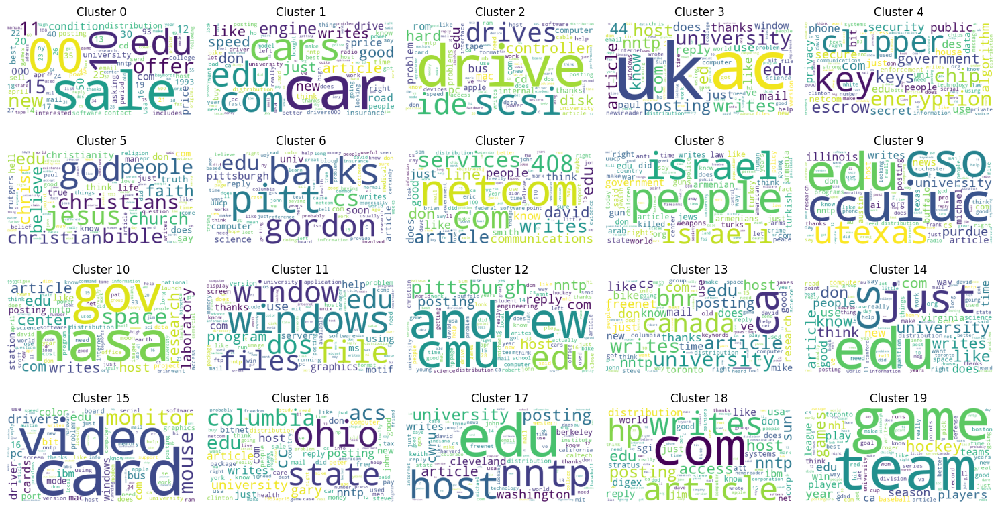

In [14]:
# Visualize cluster centers, weights based on tfidf value
fig, axes = plt.subplots(4, 5, figsize=(15, 8))
axes = axes.flatten()
words = vectorizer_tfidf.get_feature_names_out()
for c in range(n_clusters):
    # Extract data related to target
    center = kmeans.cluster_centers_[c, :]
    weights = {word : tfidf for word, tfidf in zip(words, center)}

    cloud = wordcloud.generate_from_frequencies(weights)
    
    axes[c].imshow(cloud)
    axes[c].axis("off")
    axes[c].set_title(f"Cluster {c}")

plt.tight_layout()

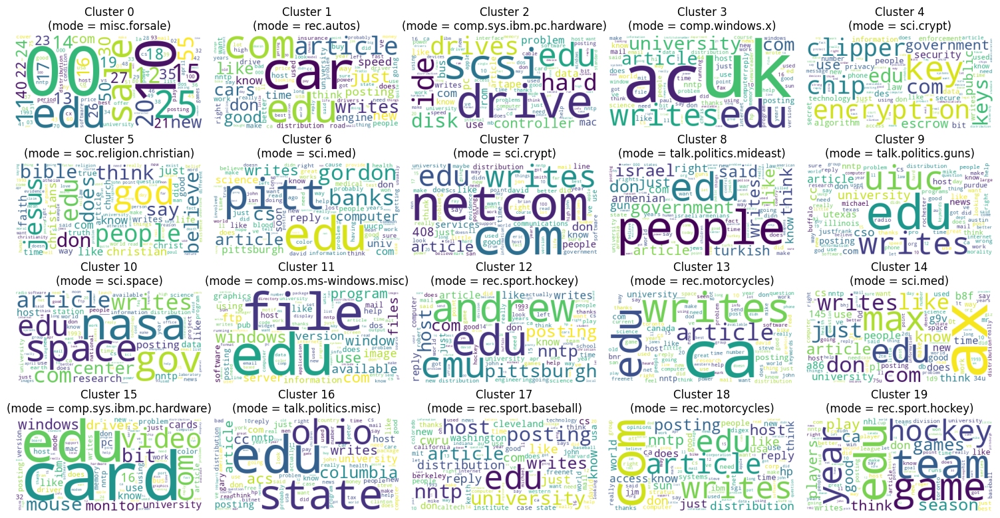

In [15]:
# Visualize cluster centers, weights based on raw frequency value
def plot_clusters_wordclouds(kmeans):
    fig, axes = plt.subplots(4, 5, figsize=(15, 8))
    axes = axes.flatten()
    words = vectorizer_tfidf.get_feature_names_out()

    for c in range(len(kmeans.cluster_centers_)):
        # Extract data related to target
        idx = np.where(kmeans.labels_ == c)[0]
        data_cluster = [newsgroups_train.data[i] for i in idx]
        # Extract frequencies
        vectors = CountVectorizer(vocabulary=words, lowercase=True).fit_transform(data_cluster)
        freqs = {word : int(freq) for word, freq in zip(words, vectors.sum(axis=0).A1)}
        cloud = wordcloud.generate_from_frequencies(freqs)

        mode = stats.mode(newsgroups_train.target[idx]).mode
        
        axes[c].imshow(cloud)
        axes[c].axis("off")
        axes[c].set_title(f"Cluster {c}\n(mode = {newsgroups_train.target_names[mode]})")

    plt.tight_layout()
plot_clusters_wordclouds(kmeans)

In [16]:
# Compute purity
def compute_purities(kmeans):    
    purities = []
    purities_norm = []
    for c in range(len(kmeans.cluster_centers_)):
        idx = np.where(kmeans.labels_ == c)[0]
        targets = newsgroups_train.target[idx]
        count = stats.mode(targets).count
        
        purities.append(count)
        purities_norm.append(count / len(targets))

    print("Normalized purities per cluster", np.array(purities_norm))
    print("Purity =", np.sum(purities) / len(newsgroups_train.data))

    # Closer to 1 -> more partitions are identical
    print("Rand score", sklearn.metrics.rand_score(newsgroups_train.target, kmeans.labels_))

    # Closer to 1, the better (less random). Closer to 0 -> no better than random
    print("Adjusted rand score", sklearn.metrics.adjusted_rand_score(newsgroups_train.target, kmeans.labels_))
compute_purities(kmeans)

Normalized purities per cluster [0.6152019  0.7745098  0.55172414 0.15430267 0.95341615 0.62105263
 0.97938144 0.14522822 0.53       0.07631579 0.46387833 0.36726804
 0.2392638  0.15789474 0.10167254 0.29710145 0.20430108 0.11463415
 0.12884753 0.60743802]
Purity = 0.3017500441930352
Rand score 0.8823682422919308
Adjusted rand score 0.10730567395686359


# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


In [37]:
lsa = sklearn.decomposition.TruncatedSVD(n_components=20)
X_reduced = lsa.fit_transform(vectors_tfidf)
V = lsa.components_ # words in topics space
Sigma = np.diag(lsa.singular_values_) # topics
U = X_reduced @ np.diag(1/lsa.singular_values_) # documents in topics space

Normalized purities per cluster [0.4556213  0.52631579 0.15384615 0.1510101  0.61484099 0.12480858
 0.53717472 0.45878136 0.13297394 0.55009107 0.52442997 0.22754491
 0.10600707 0.17267552 0.94545455 0.6460177  1.         0.48021583
 0.27554745 0.97      ]
Purity = 0.33188969418419656
Rand score 0.8907789741812515
Adjusted rand score 0.12898523494284128


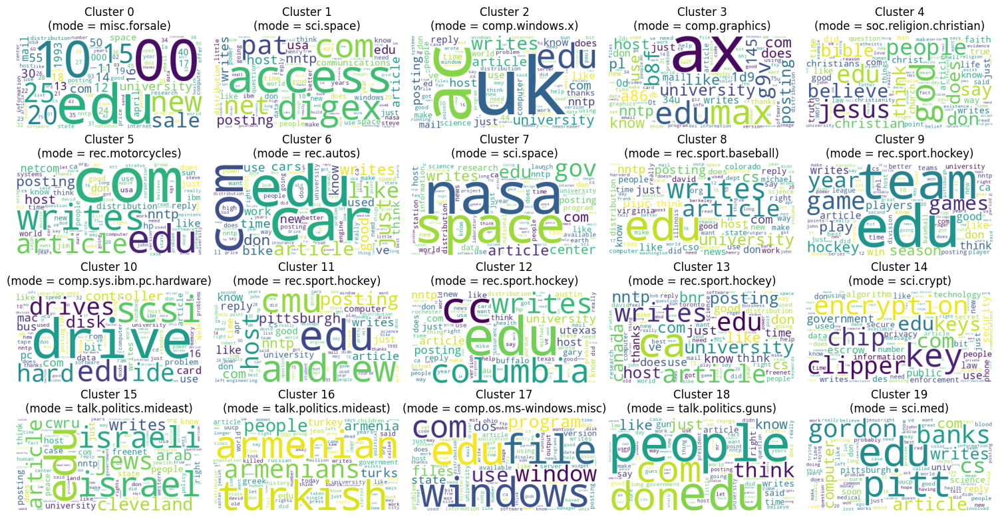

In [38]:
# K-means (without normalization)
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=0, max_iter=10).fit(U)
plot_clusters_wordclouds(kmeans)
compute_purities(kmeans)

Normalized purities per cluster [0.37414966 0.14842904 0.14951456 0.28503563 0.6002886  0.15207373
 0.21126761 0.60674157 0.1015299  0.54614221 0.88679245 0.44121715
 0.09882353 0.43485342 0.6043956  0.1319797  0.43847875 0.16006885
 0.4766147  0.36302895]
Purity = 0.34665016793353365
Rand score 0.918383835429184
Adjusted rand score 0.17636803599724282


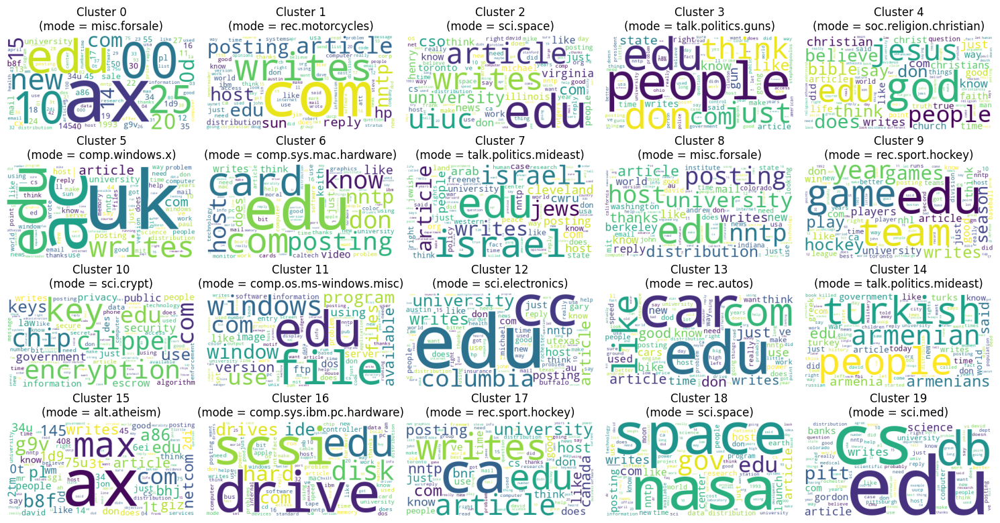

In [39]:
# K-means (with normalization)
n_clusters = 20
U_norm = U / np.linalg.norm(U, axis=1, keepdims=True)
kmeans = KMeans(n_clusters=n_clusters, random_state=0, max_iter=10).fit(U_norm)
plot_clusters_wordclouds(kmeans)
compute_purities(kmeans)

In [20]:
# t-SNE from the U matrix computed by LSA
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, init='pca', verbose=2)
tsne_mat = tsne.fit_transform(U)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11314 samples in 0.000s...
[t-SNE] Computed neighbors for 11314 samples in 0.120s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11314
[t-SNE] Computed conditional probabilities for sample 2000 / 11314
[t-SNE] Computed conditional probabilities for sample 3000 / 11314
[t-SNE] Computed conditional probabilities for sample 4000 / 11314
[t-SNE] Computed conditional probabilities for sample 5000 / 11314
[t-SNE] Computed conditional probabilities for sample 6000 / 11314
[t-SNE] Computed conditional probabilities for sample 7000 / 11314
[t-SNE] Computed conditional probabilities for sample 8000 / 11314
[t-SNE] Computed conditional probabilities for sample 9000 / 11314
[t-SNE] Computed conditional probabilities for sample 10000 / 11314
[t-SNE] Computed conditional probabilities for sample 11000 / 11314
[t-SNE] Computed conditional probabilities for sample 11314 / 11314
[t-SNE] Mean sigma: 0.008260
[t-SNE] Computed cond

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_13770/3518186781.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('hsv', 20)
/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_13770/3518186781.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet', 20)


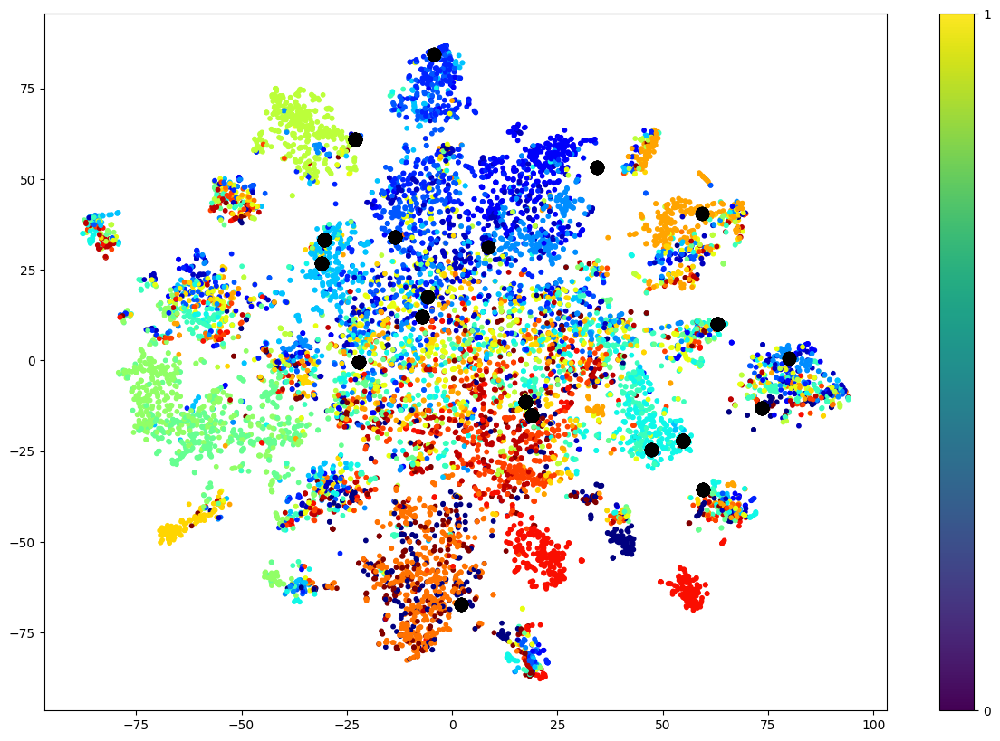

In [21]:
NN2cluster = np.argmax(np.abs(V), axis=0)
#import seaborn as sns
import matplotlib.cm as cm
cmap = cm.tab20
cmap = cm.get_cmap('hsv', 20)
cmap = cm.get_cmap('jet', 20)
#cmap = cm.tab20

plt.figure(figsize=(15,10))
plt.scatter(tsne_mat[:,0],tsne_mat[:,1], c=Y, cmap=cmap, s=10)
plt.scatter(tsne_mat[NN2cluster[:],0],tsne_mat[NN2cluster[:],1], c='black', s=100)
#plt.scatter(tsne_mat[NN2cluster2[:],0],tsne_mat[NN2cluster2[:],1], c='red', s=100)
plt.colorbar(ticks=range(20))

# 3) Latent Dirichlet Allocation (LDA)

Perform the same experiments with LDA:
- LDA
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html


**Start with a CountVectorizer**

In [22]:
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Vectorize document using TF-IDF
vectorizer = CountVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)
print(vectors.nnz / float(vectors.shape[0]))

/Users/bsh2022/.pyenv/versions/3.13.11/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(11314, 1000)
48.02527841612162


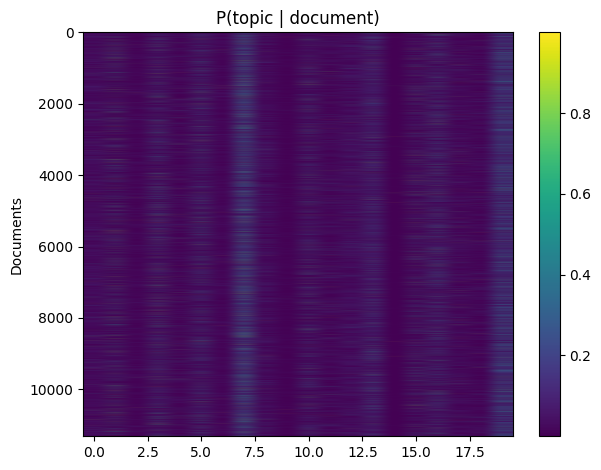

In [23]:
lda = sklearn.decomposition.LatentDirichletAllocation(n_components=20)
X_reduced = lda.fit_transform(vectors) # P(topic j | document i)

plt.imshow(X_reduced, aspect="auto")
plt.title("P(topic | document)")
plt.ylabel("Documents")
plt.colorbar()
plt.tight_layout()

Normalized purities per cluster [0.33128834 0.1861413  0.3008596  0.12587413 0.26037736 0.32570659
 0.55156951 0.17297851 0.53433208 0.18232044 0.3755102  0.19625
 0.60754717 0.3009828  0.52691218 0.42720764 0.8        0.44339623
 0.2718894  0.20149254]
Purity = 0.3166872900830829
Rand score 0.9071875633665935
Adjusted rand score 0.1413139943003886


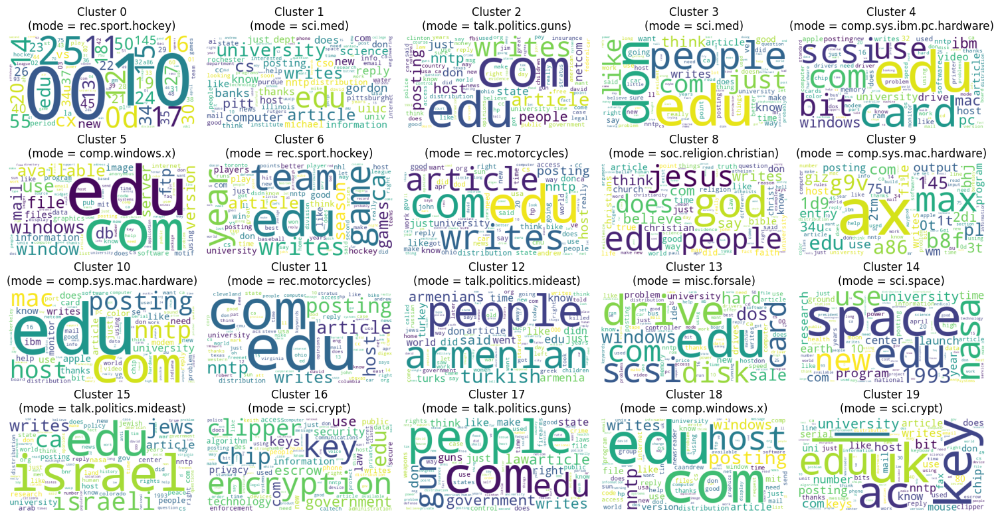

In [24]:
# K-means (with normalization)
n_clusters = 20
kmeans = KMeans(n_clusters=n_clusters, random_state=0, max_iter=10).fit(X_reduced)
plot_clusters_wordclouds(kmeans)
compute_purities(kmeans)

## LDA-viz

In [26]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 7.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 3.5 MB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pyLDAvis]4/5 [pyLDAvis]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [30]:
# pip install install pyldavis
from __future__ import print_function

import pyLDAvis
import pyLDAvis.lda_model 
pyLDAvis.enable_notebook()


pyLDAvis.lda_model.prepare(lda,vectors,vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
19    -0.168102  0.075167       1        1  13.503385
14     0.372687  0.334184       2        1   8.550718
6      0.349389  0.066714       3        1   8.326876
7     -0.112551 -0.054949       4        1   7.830510
16    -0.032034 -0.066473       5        1   7.140510
1     -0.148735  0.053065       6        1   6.214449
10    -0.169774  0.059225       7        1   5.745686
5     -0.034169 -0.082419       8        1   5.025430
0      0.308388 -0.183096       9        1   4.937900
8     -0.076583 -0.023781      10        1   4.313192
3     -0.100206 -0.052660      11        1   4.192989
13    -0.105675 -0.055297      12        1   4.064126
15    -0.072197 -0.060054      13        1   4.012983
17    -0.123044  0.060868      14        1   3.802883
2      0.062629  0.033431      15        1   2.544919
18    -0.092993  0.116960      16        1   2.355806
12    -0.025759 -0.105337      17        1   2.284542
4     -0.140957  0.069209      18        1   2.103442
11    -0.035495  0.005583      19        1   1.849777
9      0.345181 -0.190341      20        1   1.199874, topic_info=    Term          Freq         Total Category  logprob  loglift
146   ax  62655.000000  62655.000000  Default  30.0000  30.0000
0      0   9872.000000   9872.000000  Default  29.0000  29.0000
9      1  15357.000000  15357.000000  Default  28.0000  28.0000
992    x   9093.000000   9093.000000  Default  27.0000  27.0000
347  edu  21348.000000  21348.000000  Default  26.0000  26.0000
..   ...           ...           ...      ...      ...      ...
17    15     22.624452   1809.135171  Topic20  -6.3526   0.0414
443    h     24.406540   2552.673274  Topic20  -6.2768  -0.2271
62     5     30.465179   5831.714889  Topic20  -6.0551  -0.8315
407    g     27.315784   4548.045853  Topic20  -6.1642  -0.6920
10    10     20.351922   2467.423451  Topic20  -6.4585  -0.3748

[937 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
0         2  0.005267     0
0         3  0.183330     0
0         5  0.000608     0
0         9  0.051049     0
0        15  0.016510     0
...     ...       ...   ...
997      20  0.005329  york
999       2  0.062744     z
999       3  0.834920     z
999       5  0.088920     z
999      15  0.013088     z

[6378 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[20, 15, 7, 8, 17, 2, 11, 6, 1, 9, 4, 14, 16, 18, 3, 19, 13, 5, 12, 10])

# Performances evaluation

**Compare the different approaches wrt three quantitative metrics.**

Modèle | Purity (globale) | Rand Score | Adjusted Rand Score |
------ | ---------------- | ---------- | ------------------- |
Kmeans sur TF-IDF | 0.30 | 0.88 | 0.10 |
Kmeans sur LSA (20 composants, sans $l2$ normalisation) | 0.31 | 0.88 | 0.11 
Kmeans sur LSA (20 composants, avec $l2$ normalisation) | 0.34 | 0.91 | 0.18 |
Kmeans sur LDA (20 topics) | 0.31 | 0.90 | 0.14 | 
